In [147]:
#Import Test class into this notebook (needs to be in same directory)
%run test_class.ipynb

In [151]:
#Read in test data into a list of Test objects from 'vist_data' folder
path = r'visit_data' # name of folder containing test data files
filenames = glob.glob(os.path.join(path, "*.csv"))
test_list = []
for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_list.append(test)


    Analysis Start Time Analysis End Time  Velocity (km/h)  Grade (%)  \
1.0     0 days 00:07:21   0 days 00:08:01              6.7        0.0   
2.0     0 days 00:10:21   0 days 00:11:01              7.3        0.0   
3.0     0 days 00:13:19   0 days 00:13:59              8.0        0.0   
4.0     0 days 00:16:20   0 days 00:17:00              8.6        0.0   
5.0     0 days 00:19:20   0 days 00:20:00              9.2        0.0   
6.0     0 days 00:22:21   0 days 00:23:01              9.8        0.0   
7.0     0 days 00:24:13   0 days 00:24:53              9.8        2.0   

     Stage (#)  RPE (#)  Lactate (mmol/L)  VO2 (mL/min)  VO2 (mL/min/kg)  \
1.0        1.0     10.0               2.8   2419.121786        46.434211   
2.0        2.0     11.0               1.7   2524.968407        48.463529   
3.0        3.0     13.0               2.7   2842.035680        54.548235   
4.0        4.0     15.0               1.6   2918.876838        56.025500   
5.0        5.0     16.0            

/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:697: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:07:21' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis Start Time'] = str(start_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:698: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:08:01' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis End Time'] = str(end_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:723: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future versi

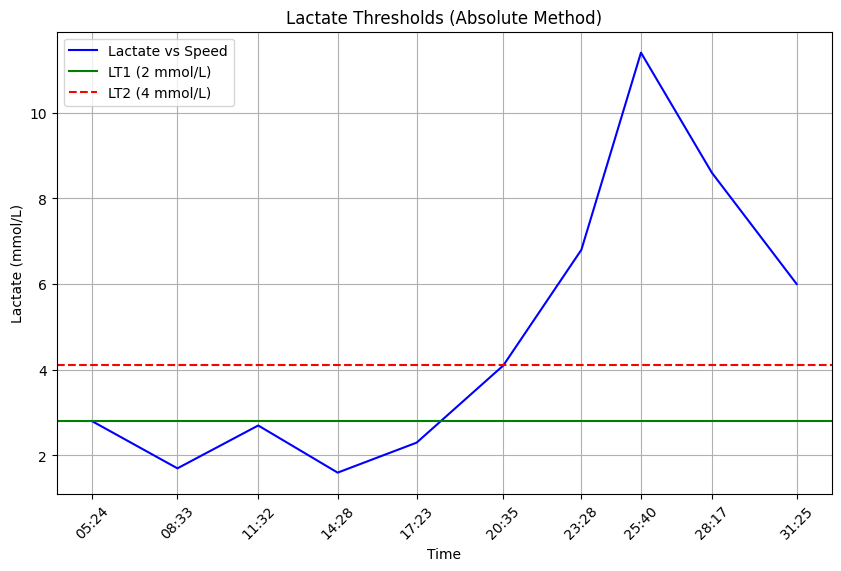

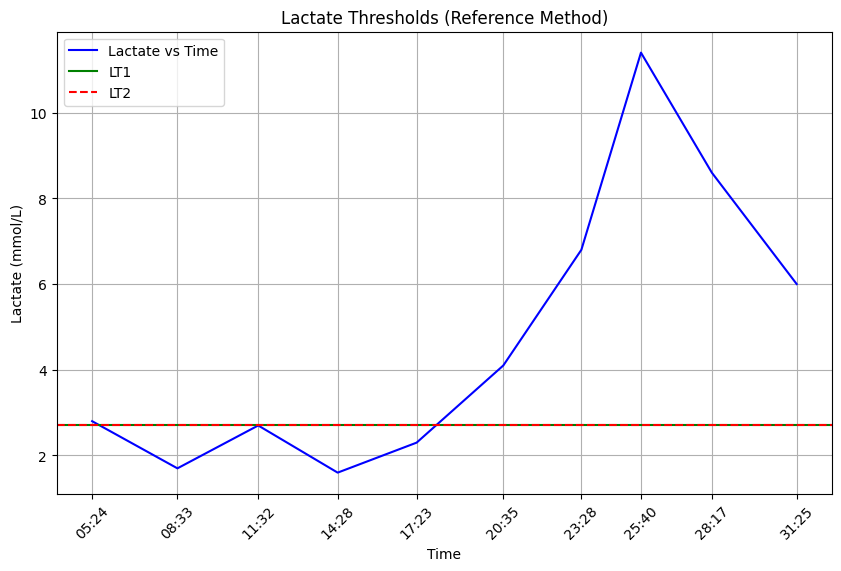

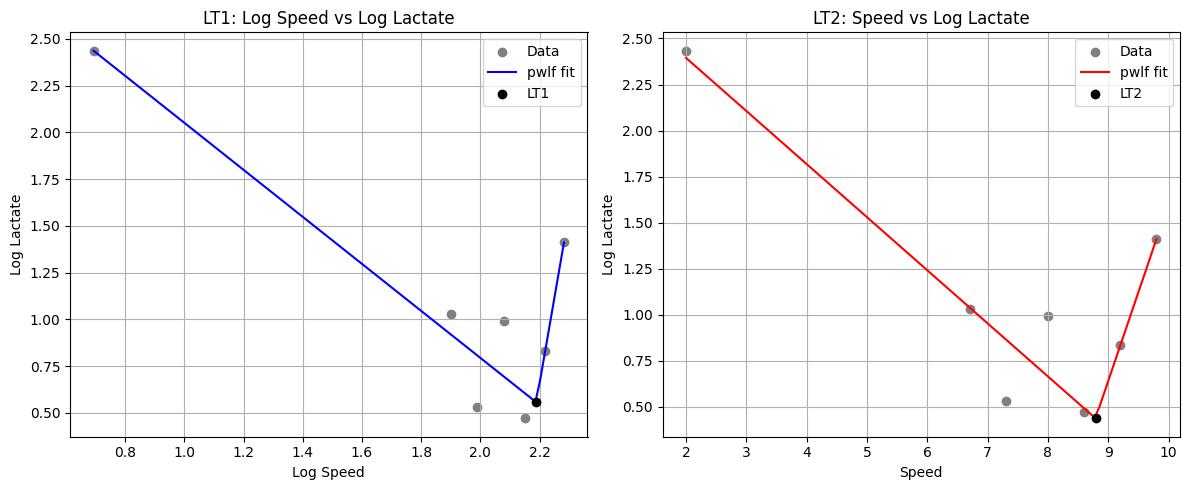

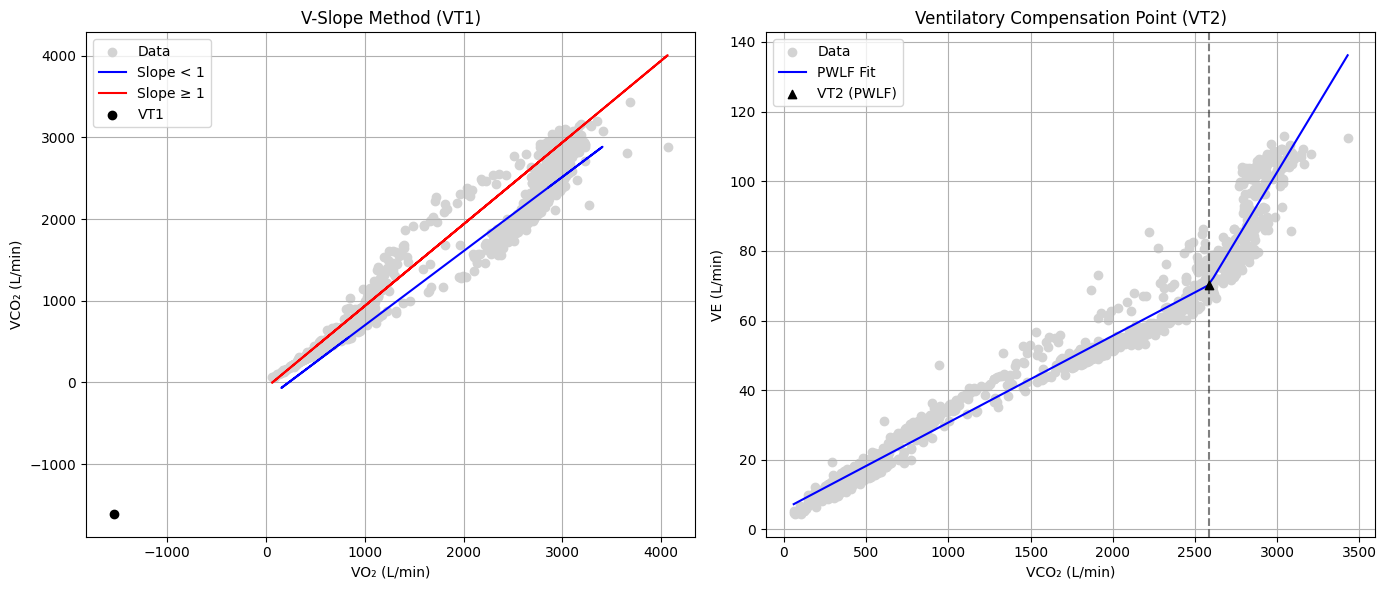

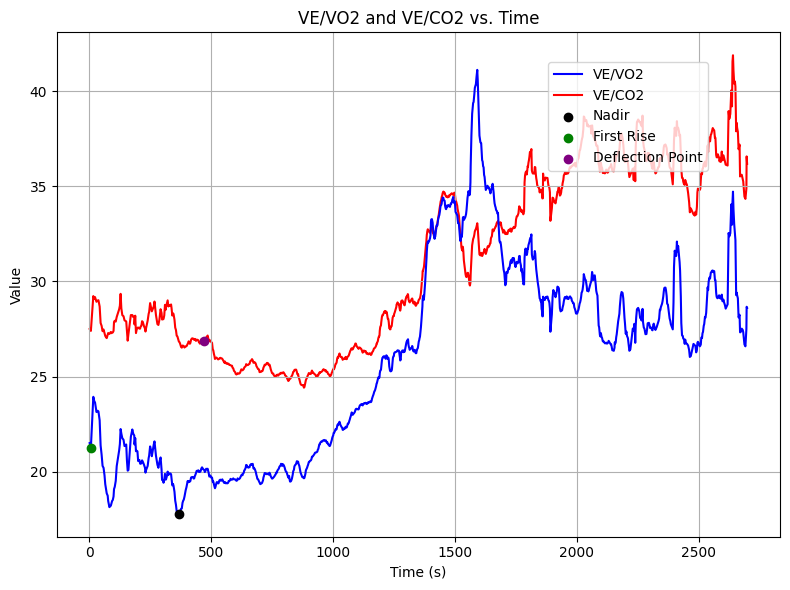

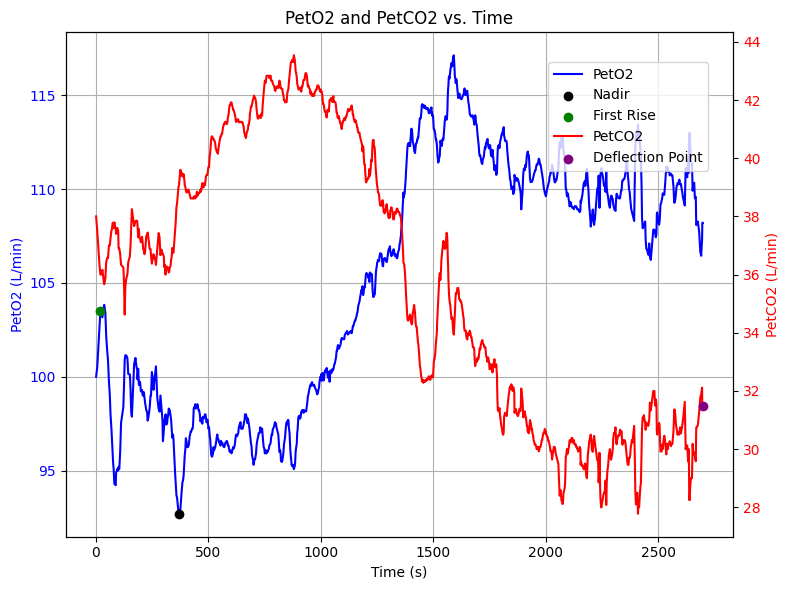

{'VO2_peak': 3081.9839470285715,
 'VO2_peak_start_time': Timedelta('0 days 00:22:25'),
 'VO2_peak_end_time': Timedelta('0 days 00:22:55'),
 'GradePeak': 0,
 'SpeedPeak': 9.8,
 'MarkerPeak': 6.0,
 'RQPeak': 0.9469565217391304,
 'HRPeak': 189.43478260869566,
 'EEMPeak': 15.325652173913044,
 'Fat%Peak': 4125.173913043478,
 'CHO%Peak': 17943.217391304348,
 'VO2/kgPeak': 59.5591304347826,
 'Lactate-VO2Peak': 6.8,
 'RPE-VO2peak': 18,
 'True_VO2max': False,
 'LT1_abs': 2.8,
 'LT2_abs': 4.1,
 'LT1_abs_speed': 6.7,
 'LT2_abs_speed': 9.8,
 'LT1_abs_grade': 0,
 'LT2_abs_grade': 0,
 'LT1_ref': 2.7,
 'LT2_ref': 2.7,
 'LT1_ref_speed': 8.0,
 'LT2_ref_speed': 8.0,
 'LT1_ref_grade': 0,
 'LT2_ref_grade': 0,
 'LT1_log': 1.743086777616514,
 'LT1_log_speed': 8.925410173748082,
 'LT1_log_r2': 0.9264078589050389,
 'LT2_semilog': 8.78931032236325,
 'LT2_semilog_speed': 1.5484039687860593,
 'LT2_semi_log_r2': 0.9169666819615617,
 'vt1_vo2_level_vo2_vo2': -1542.350330091128,
 'vt1_vo2_level_vo2_vco2': -1609.390

In [149]:
# Analyze a single test 

df_1 = pd.read_csv('visit_data/TR000100_20220203_MiPACE_visit_data.csv') 
test_1 = Test(df_1)
"""
create_test_summary() method creates a dataframe containing summary statistics for the test with rows for each stage
and columns for the following metrics:
- Start Time: The start time of the analysis window.
- End Time: The end time of the analysis window.
- Velocity (km/h)
- Grade (%)
- Stage (#)
- RPE (at end of stage)
- Lactate (mmol/L): The first lactate measurement after the end of the stage or the last measurement prior if none after.
- VO2 (L/min): Average VO2 during analysis window.
- VO2 (ml/kg/min): Average VO2/weight during analysis window.
- HR (bpm): Average HR during analysis window.
- RQ: Average RQ during analysis window.
- True VO2 max: True if the average RQ during the analysis window is greater than rq_threshold.
- Steady State: True if variance (std/mean) for smoothed VO2 is less than steady_state_threshold.

Parameters (all optional):
window_size_seconds: int, default=50
    The window size in seconds calculations (final x seconds of stage).
rq_threshold: float, default=1.0
    The RQ threshold to determine if it is a true VO2 max.
smoothing_window: int, default=3
    The window size for smoothing to calculate the rolling mean and standard deviation for steady state calculations.
steady_state_threshold: float, default=0.02
    The steady state threshold for variance of VO2.
"""
summary = test_1.create_test_summary(window_size_seconds=40, rq_threshold=1.1, smoothing_window=5, steady_state_threshold=0.05)  
print(summary)
"""
get_all_metrics() method returns a dictionary containing VO2 max, VT1/VT2, and LT1/LT2 metrics for the test. 
Error related entries are included if a specific metric could not be calculated.

Parameters (all optional):
vo2_window_size_seconds: int, default=50
    The window size in seconds to calculate VO2 max.
vt_window_size_seconds: int, default=30
    The window size in seconds to calculate VT1/VT2.
rq_threshold: float, default=1.0
    The RQ threshold to determine if it is a true VO2 max.
plot: bool, default=False
    If True, plots corresponding figures for the metric calculation.
    **Note that this will create figures for all LT1/LT2 and VT1/VT2 methods, to plot individual graphs, functions must run seperately**
    Only use for limited numbers of tests, as it will create a lot of figures.
"""
test_1.get_all_metrics(plot=True)

In [154]:

summary_folder = 'stage_summaries' # name of folder to save summary files
rows = []
for test in test_list:
    result = test.get_all_metrics() 
    result['name'] = test.name
    rows.append(result)
    summary = test.create_test_summary()
    summary.to_parquet(f"{summary_folder}/{test.name}_summary.parquet", index=False)
    #summary.to_csv(f"{summary_folder}/{test.name}_summary.csv", index=False)

df = pd.DataFrame(rows).set_index('name')
df.to_parquet(f"combined_summaries.parquet")
#df.to_csv(f"combined_summaries.csv")


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:697: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:08:23' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis Start Time'] = str(start_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:698: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:09:13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Analysis End Time'] = str(end_time).split('.')[0]
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_58202/1182259817.py:723: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future versi

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, TR000207_20221201 to TR000138_20220414
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   VO2_peak                         605 non-null    float64        
 1   VO2_peak_start_time              605 non-null    timedelta64[ns]
 2   VO2_peak_end_time                605 non-null    timedelta64[ns]
 3   GradePeak                        605 non-null    float64        
 4   SpeedPeak                        605 non-null    float64        
 5   MarkerPeak                       605 non-null    float64        
 6   RQPeak                           605 non-null    float64        
 7   HRPeak                           605 non-null    float64        
 8   EEMPeak                          605 non-null    float64        
 9   Fat%Peak                         605 non-null    float64        
 10  CHO%Peak                 